# Chapter 10 Physics-Informed Neural Network
## Rahul Bhadani

# 1. Example 1

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class PINN(nn.Module):
    def __init__(self, hidden_size: int = 20):
        super().__init__()

        # Network layers
        self.layer1 = nn.Linear(1, hidden_size)
        self.layer2 = nn.Linear(hidden_size, hidden_size)
        self.layer3 = nn.Linear(hidden_size, 1)

        # Activation
        self.activation = nn.Tanh()

        self._init_weights()
    
    def _init_weights(self):
        for layer in [self.layer1, self.layer2, self.layer3]:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.activation(self.layer1(x))
        x = self.activation(self.layer2(x))
        x = self.layer3(x)
        return x        
    
    
    def ode_residual(self, x: torch.Tensor) -> torch.Tensor:
        """Computes  dy/dx + 2y  at every collocation point x."""
        y = self.forward(x)
        dy_dx = torch.autograd.grad(
            outputs      = y,
            inputs       = x,
            grad_outputs = torch.ones_like(y),
            create_graph = True,        # needed so .backward() reaches weights
        )[0]
        return dy_dx + 2.0 * y
    
    
    def ic_residual(self) -> torch.Tensor:
        """Computes  (y(0) − 1)^2  — the initial-condition penalty."""
        x0 = torch.zeros(1, 1)
        return (self.forward(x0) - 1.0) ** 2
    
    
    def loss(
        self,
        x: torch.Tensor,
        lambda_ode: float = 1.0,
        lambda_ic:  float = 10.0,       # weight IC more heavily
    ) -> torch.Tensor:
        
        loss_ode = lambda_ode * torch.mean(self.ode_residual(x) ** 2)
        loss_ic  = lambda_ic  * self.ic_residual()
        return loss_ode + loss_ic

In [3]:
model     = PINN(hidden_size=20)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [14]:
# Collocation points — requires_grad so autograd can differentiate w.r.t. x
#x_train = torch.linspace(0, 2, 100).view(-1, 1).requires_grad_(True)

x_train = torch.rand(10, 1) * 2   # 10 random points in [0, 2]
x_train.requires_grad_(True)

tensor([[1.5033],
        [0.7867],
        [0.8452],
        [1.9677],
        [0.4309],
        [0.5800],
        [1.6497],
        [1.0773],
        [1.5811],
        [0.5171]], requires_grad=True)

In [15]:
loss_history = []

for epoch in range(100000):
    optimizer.zero_grad()
    loss = model.loss(x_train)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 5000 == 0:
        print(f"Epoch {epoch:5d}  |  Loss: {loss.item():.4e}")

Epoch     0  |  Loss: 5.1785e-07
Epoch  5000  |  Loss: 2.2256e-07
Epoch 10000  |  Loss: 1.8841e-07
Epoch 15000  |  Loss: 1.6875e-07
Epoch 20000  |  Loss: 3.4523e-06
Epoch 25000  |  Loss: 3.8041e-07
Epoch 30000  |  Loss: 1.4649e-07
Epoch 35000  |  Loss: 1.4139e-07
Epoch 40000  |  Loss: 1.3748e-07
Epoch 45000  |  Loss: 1.3425e-07
Epoch 50000  |  Loss: 1.4350e-07
Epoch 55000  |  Loss: 1.2717e-07
Epoch 60000  |  Loss: 1.3009e-07
Epoch 65000  |  Loss: 1.2381e-07
Epoch 70000  |  Loss: 1.1768e-07
Epoch 75000  |  Loss: 1.1475e-07
Epoch 80000  |  Loss: 1.1268e-07
Epoch 85000  |  Loss: 1.2348e-07
Epoch 90000  |  Loss: 1.0614e-07
Epoch 95000  |  Loss: 1.0327e-07


In [16]:
x_test = torch.linspace(0, 2, 300).view(-1, 1)

with torch.no_grad():
    y_pred = model(x_test).numpy()

y_true = np.exp(-2.0 * x_test.numpy())

abs_err = np.abs(y_pred - y_true)
print(f"\nMax absolute error  : {abs_err.max():.2e}")
print(f"Mean absolute error : {abs_err.mean():.2e}")
print(f"Relative L2 error   : {np.linalg.norm(y_pred - y_true) / np.linalg.norm(y_true):.2e}")



Max absolute error  : 1.17e-03
Mean absolute error : 5.83e-04
Relative L2 error   : 1.82e-03


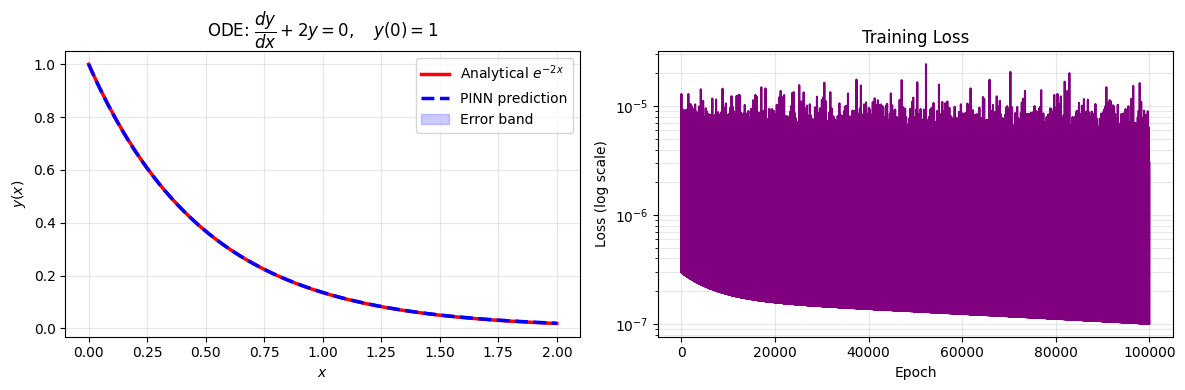

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


ax = axes[0]
ax.plot(x_test.numpy(), y_true, "r-",  lw=2.5, label=r"Analytical $e^{-2x}$")
ax.plot(x_test.numpy(), y_pred, "b--", lw=2.5, label="PINN prediction")
ax.fill_between(
    x_test.numpy().ravel(),
    y_true.ravel() - abs_err.ravel(),
    y_true.ravel() + abs_err.ravel(),
    alpha=0.2, color="blue", label="Error band",
)
ax.set_xlabel("$x$");  ax.set_ylabel("$y(x)$")
ax.set_title(r"ODE: $\dfrac{dy}{dx} + 2y = 0,\quad y(0)=1$")
ax.legend();  ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(loss_history, color="purple", lw=1.5)
ax.set_xlabel("Epoch");  ax.set_ylabel("Loss (log scale)")
ax.set_title("Training Loss")
ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("pinn_class.png", dpi=150, bbox_inches="tight")
plt.show()

## Inference on extrapolated points

In [18]:
x_extrap = torch.linspace(0, 4, 200).view(-1, 1)

with torch.no_grad():
    y_extrap_pred = model(x_extrap).numpy()

y_extrap_true = np.exp(-2.0 * x_extrap.numpy())

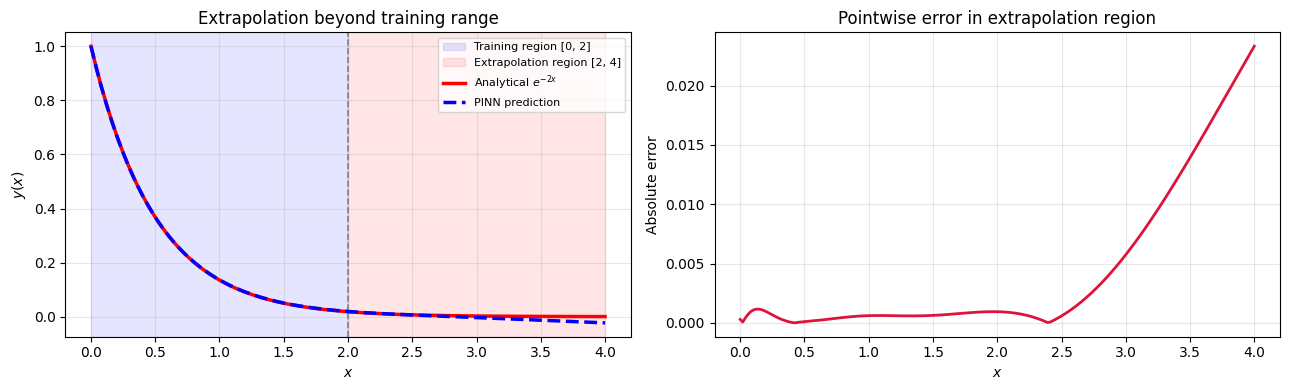

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left — full picture: training + extrapolation
ax = axes[0]
ax.axvspan(0, 2, alpha=0.10, color="blue",  label="Training region [0, 2]")
ax.axvspan(2, 4, alpha=0.10, color="red",   label="Extrapolation region [2, 4]")
ax.axvline(x=2, color="gray", linestyle="--", lw=1.2)

ax.plot(x_extrap.numpy(), y_extrap_true, "r-",  lw=2.5, label=r"Analytical $e^{-2x}$")
ax.plot(x_extrap.numpy(), y_extrap_pred, "b--", lw=2.5, label="PINN prediction")

ax.set_xlabel("$x$");  ax.set_ylabel("$y(x)$")
ax.set_title("Extrapolation beyond training range")
ax.legend(fontsize=8);  ax.grid(True, alpha=0.3)

ax = axes[1]
abs_err_extrap = np.abs(y_extrap_pred - y_extrap_true)
ax.plot(x_extrap.numpy(), abs_err_extrap, color="crimson", lw=2)
ax.set_xlabel("$x$");  ax.set_ylabel("Absolute error")
ax.set_title("Pointwise error in extrapolation region")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
print(f"Max absolute error  : {abs_err_extrap.max():.2e}")
print(f"Mean absolute error : {abs_err_extrap.mean():.2e}")
print(f"Relative L2 error   : {np.linalg.norm(y_extrap_pred - y_extrap_true) / np.linalg.norm(y_extrap_true):.2e}")

Max absolute error  : 2.33e-02
Mean absolute error : 4.29e-03
Relative L2 error   : 3.02e-02
